## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---


## Preliminary if Using Google Colab

- Recommended method: use `pip` with `requirements.txt` at the repository root.
- If you are in **Google Colab**, run the next code cell once to clone this repo and install dependencies.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/XinzeLee/Fundamentals_of_AI_for_PE/blob/main/5_PIML/PINN/pinn_pde.ipynb)


In [ ]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_dir = "/content/Fundamentals_of_AI_for_PE"
    if not os.path.isdir(repo_dir):
        !git clone https://github.com/XinzeLee/Fundamentals_of_AI_for_PE.git /content/Fundamentals_of_AI_for_PE
    %cd /content/Fundamentals_of_AI_for_PE
    !pip install -q -r requirements.txt
else:
    print(
        "Not in Google Colab — skip clone/pip. Use your local env or run: pip install -r requirements.txt from the repo root."
    )


## PINN case study: viscous Burgers equation

We solve the **1-D viscous Burgers equation**

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \qquad x \in [-1,1],\; t \in [0,T],$$

with **initial condition** $u(x,0) = -\sin(\pi x)$ and **homogeneous Dirichlet** boundaries $u(\pm 1, t) = 0$ (consistent with the IC at $x=\pm 1$).

**What this notebook demonstrates (stability-oriented practice):**
- **Ground truth:** high-accuracy reference via **method-of-lines** (central differences in $x$ + `scipy.integrate.solve_ivp`). PINN errors are reported in **relative $L_2$** on a dense test grid.
- **Input preconditioning:** map $(x,t)$ to centered, scaled coordinates fed to the MLP (roughly unit range).
- **Output scaling:** bounded `tanh` head so $u$ stays in a plausible range matching the problem scale.
- **Fixed training sets:** **PDE collocation**, **boundary**, and **initial** points are chosen once as **deterministic grids** (tensor products / linspaces), not resampled each step.
- **Soft IC / BC:** the network predicts $u(x,t)$ directly; **initial** and **Dirichlet boundary** conditions are imposed through **MSE penalty terms** in the loss (learnable approximation, not an exact ansatz).
- **Balanced composite loss:** $L = \lambda_{\mathrm{pde}} L_{\mathrm{pde}} + \lambda_{\mathrm{ic}} L_{\mathrm{ic}} + \lambda_{\mathrm{bc}} L_{\mathrm{bc}}$ with scalar weights.
- **Optimizer mix:** **Adam** with **gradient clipping** + **ReduceLROnPlateau**, then optional **L-BFGS** on the **same** composite objective.

> For stiff convection-dominated regimes (very small $\nu$), PINNs typically need more collocation points, Fourier features, or specialized architectures; here we use moderate $\nu$ so the baseline MLP PINN remains well behaved.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# --- Problem setup (physical domain) ---
nu = 0.01  # viscosity
T_final = 1.0
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, T_final


def u_initial(x):
    return -np.sin(np.pi * np.asarray(x))


print("device:", device, "| nu =", nu)

device: cuda | nu = 0.01


### Reference solution (method of lines)

Semi-discrete interior ODEs with second-order central differences and Dirichlet boundaries $u_0=u_{N-1}=0$.

reference ODE done, nfev = 5504


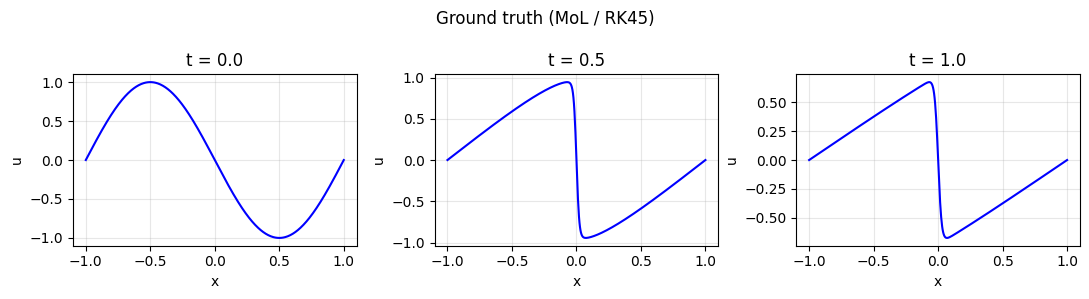

In [2]:
def burgers_reference_mol(nx: int = 513, rtol: float = 1e-9, atol: float = 1e-11):
    x = np.linspace(x_min, x_max, nx)
    dx = (x_max - x_min) / (nx - 1)
    interior = slice(1, nx - 1)

    def rhs(t, u_int):
        u_full = np.zeros(nx)
        u_full[interior] = u_int
        ux = (u_full[2:] - u_full[:-2]) / (2 * dx)
        uxx = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / (dx**2)
        u_mid = u_int
        return -u_mid * ux + nu * uxx

    u0_full = u_initial(x)
    u0_int = u0_full[interior]
    sol = solve_ivp(
        rhs,
        (0.0, T_final),
        u0_int,
        method="RK45",
        rtol=rtol,
        atol=atol,
        dense_output=True,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    def u_of(xq, tq):
        xq = np.asarray(xq, dtype=np.float64).ravel()
        tq = np.asarray(tq, dtype=np.float64).ravel()
        vals = []
        for ti in tq:
            u_int = sol.sol(ti)
            u_full = np.zeros(nx)
            u_full[interior] = u_int
            vals.append(np.interp(xq, x, u_full))
        return np.stack(vals, axis=0).reshape(tq.shape + xq.shape)

    return x, sol, u_of


x_ref, sol_ref, u_ref_fn = burgers_reference_mol(nx=513)
print("reference ODE done, nfev =", sol_ref.nfev)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for k, ti in enumerate([0.0, 0.5, T_final]):
    ui = u_ref_fn(x_ref, np.array([ti]))[0]
    ax[k].plot(x_ref, ui, "b-", lw=1.5)
    ax[k].set_title(f"t = {ti}")
    ax[k].set_xlabel("x")
    ax[k].set_ylabel("u")
    ax[k].grid(True, alpha=0.3)
plt.suptitle("Ground truth (MoL / RK45)")
plt.tight_layout()
plt.show()


### PINN: fixed collocation / IC / BC points, soft (learnable) IC and BC

In [3]:
class BurgersPINN(nn.Module):
    def __init__(self, hidden=64, layers=6, u_scale: float = 1.0):
        super().__init__()
        self.u_scale = u_scale
        # map physical (x,t) to ~ unit box
        self.register_buffer("x0", torch.tensor((x_min + x_max) / 2.0))
        self.register_buffer("sx", torch.tensor(2.0 / (x_max - x_min)))
        self.register_buffer("t0", torch.tensor((t_min + t_max) / 2.0))
        self.register_buffer("st", torch.tensor(2.0 / (t_max - t_min)))
        nets = []
        nets.append(nn.Linear(2, hidden))
        for _ in range(layers - 1):
            nets.append(nn.Tanh())
            nets.append(nn.Linear(hidden, hidden))
        nets.append(nn.Tanh())
        nets.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*nets)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def _coords(self, x, t):
        xn = (x - self.x0) * self.sx
        tn = (t - self.t0) * self.st
        return torch.cat([xn, tn], dim=-1)

    def forward(self, x, t):
        raw = self.net(self._coords(x, t))
        return self.u_scale * torch.tanh(raw)


def pde_residual(model, x, t):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    f = u_t + u * u_x - nu * u_xx
    return f


def fixed_collocation_points(nx_f: int, nt_f: int, device):
    """Tensor-product grid in (x, t), fixed for all training steps."""
    x = np.linspace(x_min, x_max, nx_f, dtype=np.float64)
    t = np.linspace(t_min, t_max, nt_f, dtype=np.float64)
    X, T = np.meshgrid(x, t, indexing="xy")
    xf = torch.tensor(X.ravel(), device=device, dtype=torch.float32).view(-1, 1)
    tf = torch.tensor(T.ravel(), device=device, dtype=torch.float32).view(-1, 1)
    return xf, tf


def fixed_ic_points(n_ic: int, device):
    x = np.linspace(x_min, x_max, n_ic, dtype=np.float64)
    x_ic = torch.tensor(x, device=device, dtype=torch.float32).view(-1, 1)
    t_ic = torch.full_like(x_ic, float(t_min))
    return x_ic, t_ic


def fixed_bc_points(n_bc: int, device):
    t = np.linspace(t_min, t_max, n_bc, dtype=np.float64)
    t_bc = torch.tensor(t, device=device, dtype=torch.float32).view(-1, 1)
    x_left = torch.full_like(t_bc, float(x_min))
    x_right = torch.full_like(t_bc, float(x_max))
    return (x_left, t_bc), (x_right, t_bc)


fixed sets | collocation: 8192 | IC: 512 | BC / side: 512
trainable parameters: 12737
step     0 | L_tot=5.693e+01 | L_pde=4.886e-04 | L_ic=5.566e-01 L_bc=1.270e-02
step   100 | L_tot=3.369e+00 | L_pde=4.355e-01 | L_ic=2.024e-02 L_bc=9.091e-03
step   200 | L_tot=2.353e+00 | L_pde=4.298e-01 | L_ic=1.011e-02 L_bc=9.127e-03
step   300 | L_tot=1.308e+00 | L_pde=4.381e-01 | L_ic=6.140e-03 L_bc=2.556e-03
step   400 | L_tot=1.236e+00 | L_pde=4.163e-01 | L_ic=4.192e-03 L_bc=4.003e-03
step   500 | L_tot=1.037e+00 | L_pde=4.040e-01 | L_ic=2.784e-03 L_bc=3.547e-03
step   600 | L_tot=1.006e+00 | L_pde=3.620e-01 | L_ic=2.332e-03 L_bc=4.107e-03
step   700 | L_tot=1.044e+00 | L_pde=3.410e-01 | L_ic=2.000e-03 L_bc=5.031e-03
step   800 | L_tot=6.476e-01 | L_pde=3.357e-01 | L_ic=1.092e-03 L_bc=2.027e-03
step   900 | L_tot=5.531e-01 | L_pde=3.176e-01 | L_ic=1.098e-03 L_bc=1.257e-03
step  1000 | L_tot=7.916e-01 | L_pde=3.087e-01 | L_ic=1.429e-03 L_bc=3.400e-03
step  1100 | L_tot=7.009e-01 | L_pde=3.072e-0

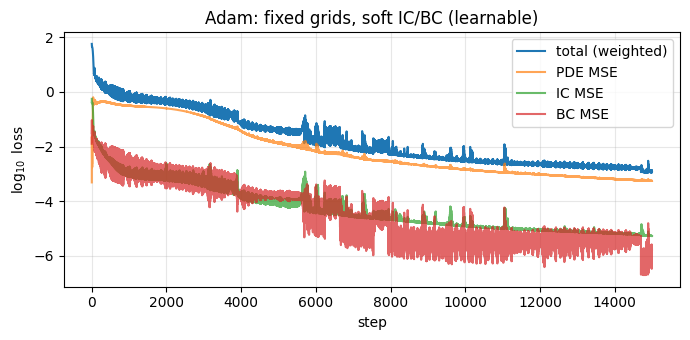

In [4]:
# --- Fixed training sets (same points every step) ---
NX_F, NT_F = 64, 128  # tensor-product PDE collocation (8192 points)
N_IC = 512
N_BC = 512
W_PDE, W_IC, W_BC = 1.0, 100.0, 100.0  # weight soft IC/BC vs PDE residual

X_F, T_F = fixed_collocation_points(NX_F, NT_F, device)
X_IC, T_IC = fixed_ic_points(N_IC, device)
(XL, TL), (XR, TR) = fixed_bc_points(N_BC, device)
print(
    "fixed sets | collocation:",
    len(X_F),
    "| IC:",
    len(X_IC),
    "| BC / side:",
    len(TL),
)

model = BurgersPINN(hidden=64, layers=4, u_scale=1.0).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("trainable parameters:", n_params)


def train_adam(model, steps=15_000, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=400, min_lr=1e-5
    )
    hist = {"total": [], "pde": [], "ic": [], "bc": []}

    for step in range(steps):
        model.train()
        opt.zero_grad(set_to_none=True)

        f = pde_residual(model, X_F, T_F)
        loss_pde = torch.mean(f**2)

        u_ic = model(X_IC, T_IC)
        u_ic_true = -torch.sin(torch.pi * X_IC)
        loss_ic = torch.mean((u_ic - u_ic_true) ** 2)
        loss_bc = torch.mean(model(XL, TL) ** 2) + torch.mean(model(XR, TR) ** 2)

        loss = W_PDE * loss_pde + W_IC * loss_ic + W_BC * loss_bc
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step(loss.detach())

        hist["total"].append(loss.item())
        hist["pde"].append(loss_pde.item())
        hist["ic"].append(loss_ic.item())
        hist["bc"].append(loss_bc.item())

        if step % 100 == 0:
            print(
                f"step {step:5d} | L_tot={loss.item():.3e} | L_pde={loss_pde.item():.3e} | "
                f"L_ic={loss_ic.item():.3e} L_bc={loss_bc.item():.3e}"
            )
    return hist


hist = train_adam(model, steps=15000, lr=1e-3)

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
eps = 1e-16
ax.plot(np.log10(np.maximum(hist["total"], eps)), label="total (weighted)")
ax.plot(np.log10(np.maximum(hist["pde"], eps)), alpha=0.7, label="PDE MSE")
ax.plot(np.log10(np.maximum(hist["ic"], eps)), alpha=0.7, label="IC MSE")
ax.plot(np.log10(np.maximum(hist["bc"], eps)), alpha=0.7, label="BC MSE")
ax.set_xlabel("step")
ax.set_ylabel(r"$\log_{10}$ loss")
ax.legend()
ax.set_title("Adam: fixed grids, soft IC/BC (learnable)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
def train_lbfgs(model, steps=800):
    opt = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        history_size=50,
        line_search_fn="strong_wolfe",
    )
    last_loss = [0.0]

    def closure():
        opt.zero_grad(set_to_none=True)
        f = pde_residual(model, X_F, T_F)
        loss_pde = torch.mean(f**2)
        u_ic = model(X_IC, T_IC)
        u_ic_true = -torch.sin(torch.pi * X_IC)
        loss_ic = torch.mean((u_ic - u_ic_true) ** 2)
        loss_bc = torch.mean(model(XL, TL) ** 2) + torch.mean(model(XR, TR) ** 2)
        loss = W_PDE * loss_pde + W_IC * loss_ic + W_BC * loss_bc
        loss.backward()
        last_loss[0] = loss.item()
        return loss

    for i in range(steps):
        opt.step(closure)
        if i % 100 == 0:
            print(f"L-BFGS iter {i:4d} | L = {last_loss[0]:.3e}")


train_lbfgs(model, steps=500)


L-BFGS iter    0 | L = 1.091e-03
L-BFGS iter  100 | L = 1.424e-04
L-BFGS iter  200 | L = 6.574e-05
L-BFGS iter  300 | L = 4.197e-05
L-BFGS iter  400 | L = 3.922e-05


### Validation vs ground truth

Relative L2 error on test grid: 3.8092e-03
Max absolute error:            3.4771e-02


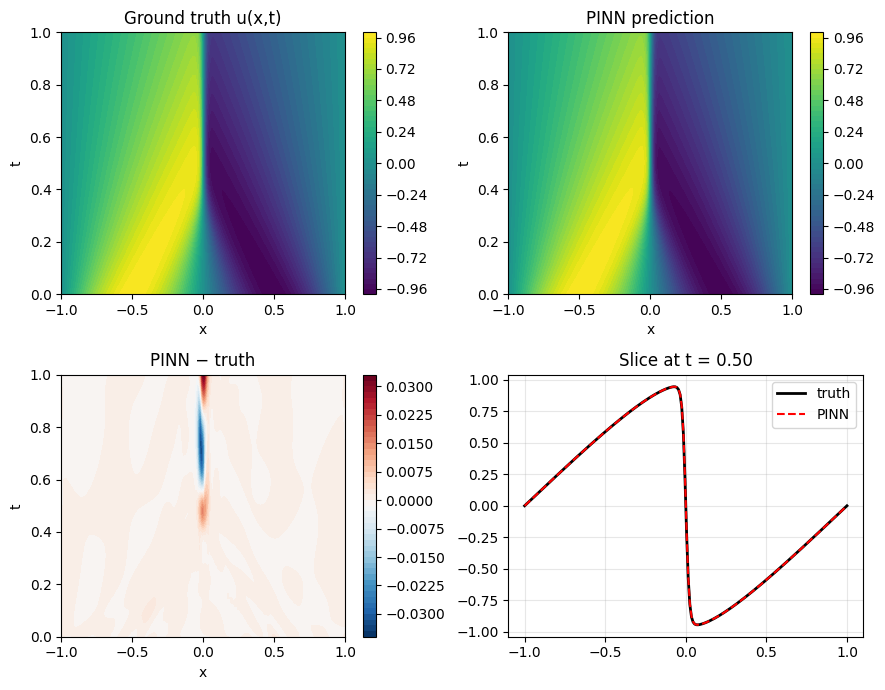

In [6]:
nx_t = 200
nt_t = 150
xg = np.linspace(x_min, x_max, nx_t)
tg = np.linspace(t_min, t_max, nt_t)
Xg, Tg = np.meshgrid(xg, tg)

u_true = u_ref_fn(xg, tg)

model.eval()
with torch.no_grad():
    xt = torch.tensor(Xg.ravel(), device=device, dtype=torch.float32).view(-1, 1)
    tt = torch.tensor(Tg.ravel(), device=device, dtype=torch.float32).view(-1, 1)
    u_pred = model(xt, tt).cpu().numpy().reshape(Xg.shape)

diff = u_pred - u_true
l2_rel = np.linalg.norm(diff.ravel()) / (np.linalg.norm(u_true.ravel()) + 1e-12)
l_inf = np.max(np.abs(diff))

print(f"Relative L2 error on test grid: {l2_rel:.4e}")
print(f"Max absolute error:            {l_inf:.4e}")

fig, ax = plt.subplots(2, 2, figsize=(9, 7))
c0 = ax[0, 0].contourf(Xg, Tg, u_true, 50, cmap="viridis")
plt.colorbar(c0, ax=ax[0, 0])
ax[0, 0].set_title("Ground truth u(x,t)")
ax[0, 0].set_xlabel("x")
ax[0, 0].set_ylabel("t")

c1 = ax[0, 1].contourf(Xg, Tg, u_pred, 50, cmap="viridis")
plt.colorbar(c1, ax=ax[0, 1])
ax[0, 1].set_title("PINN prediction")
ax[0, 1].set_xlabel("x")
ax[0, 1].set_ylabel("t")

c2 = ax[1, 0].contourf(Xg, Tg, diff, 50, cmap="RdBu_r")
plt.colorbar(c2, ax=ax[1, 0])
ax[1, 0].set_title("PINN − truth")
ax[1, 0].set_xlabel("x")
ax[1, 0].set_ylabel("t")

idx = nt_t // 2
ax[1, 1].plot(xg, u_true[idx], "k-", lw=2, label="truth")
ax[1, 1].plot(xg, u_pred[idx], "r--", lw=1.5, label="PINN")
ax[1, 1].set_title(f"Slice at t = {tg[idx]:.2f}")
ax[1, 1].legend()
ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
